Fruit Basket Dataset:
    Weight  Size  Color_Score   Fruit
0      120     5            8   Apple
1      130     5            9   Apple
2      125     5            8   Apple
3      140     6            9   Apple
4      150     6            8   Apple
5      155     6            9   Apple
6      160     7            8   Apple
7      170     7            9   Apple
8      180     7            8   Apple
9      185     8            9   Apple
10     190     8            8   Apple
11     200     8            9   Apple
12     210     9            8   Apple
13     220     9            9   Apple
14     230     9            8   Apple
15     240    10            9   Apple
16     250    10            8   Apple
17     260    10            9   Apple
18     270    11            8   Apple
19     280    11            9   Apple
20     110     4            6  Banana
21     115     4            7  Banana
22     135     5            6  Banana
23     145     6            7  Banana
24     165     7            

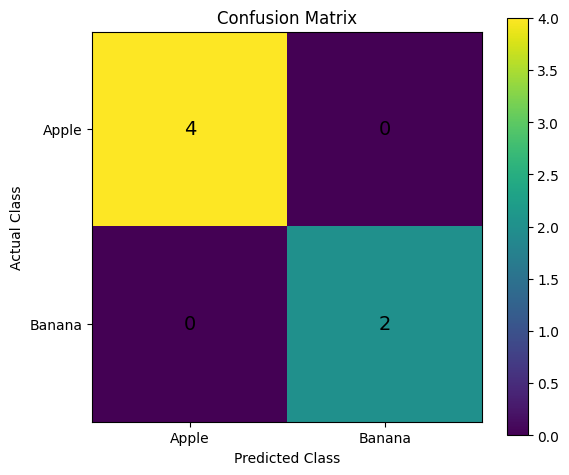


Classification Report:
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00         4
      Banana       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


New Fruit:
   Weight  Size  Color_Score
0     175     7            8
Tree 1: 1.0
Tree 2: 0.0
Tree 3: 0.0
Tree 4: 0.0
Tree 5: 0.0
Tree 6: 1.0
Tree 7: 0.0
Tree 8: 0.0
Tree 9: 0.0
Tree 10: 1.0

Tree Predictions:
[np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0)]

Votes:
0.0    7
1.0    3
Name: count, dtype: int64

Final Class after Majority Voting:
0.0

Feature Importance:
       Feature  Importance
2  Color_Score    0.642158
1         Size    0.267353
0       Weight    0.090489


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: U

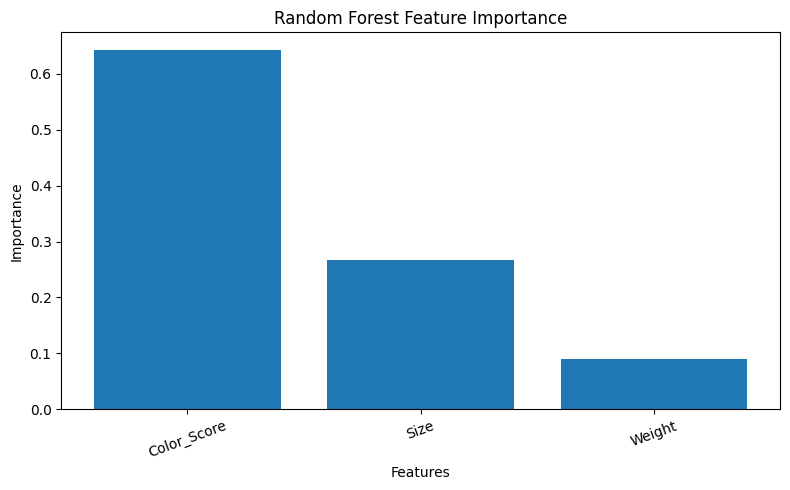

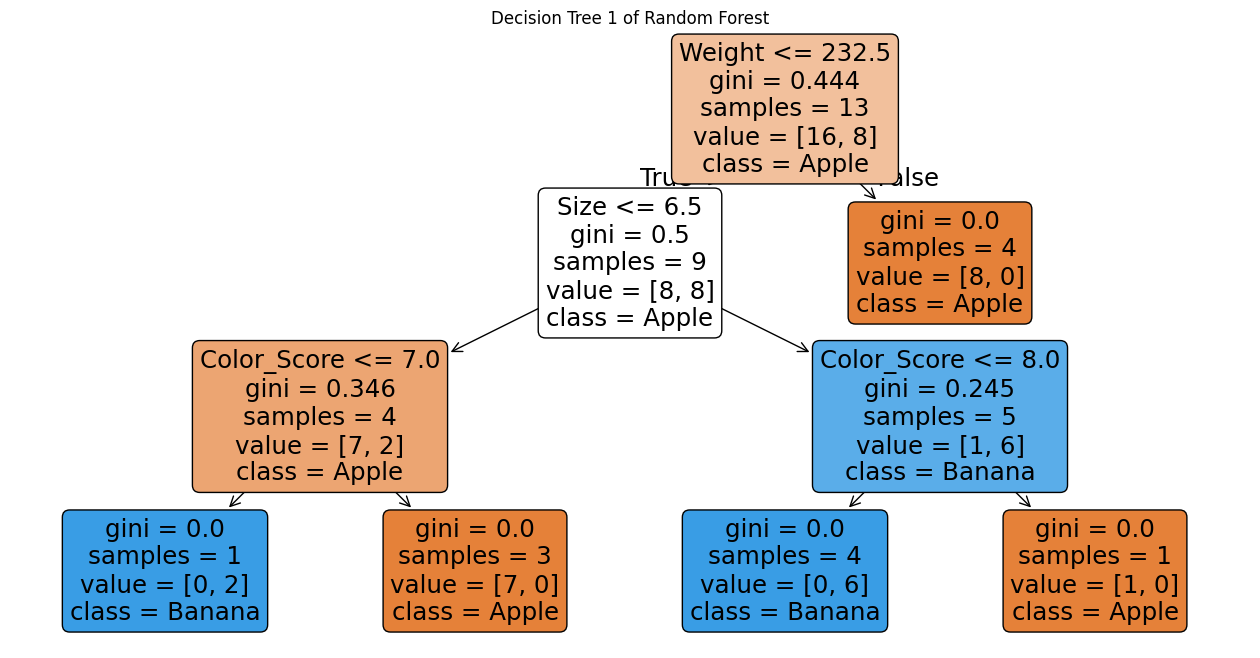


Predictions for New Fruits:
   Weight  Size  Color_Score Predicted_Fruit
0     125     5            8           Apple
1     175     7            8           Apple
2     250    10            9           Apple
3     140     6            9           Apple
4     200     8            8           Apple

Random Forest classification was successfully implemented.
Multiple Decision Trees were trained using different samples of the data.
Each tree produced an individual prediction.
The final prediction was obtained using majority voting.
The Random Forest model was evaluated using accuracy,
confusion matrix, classification report, and feature importance.


In [1]:
# 1. Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 2. Create fruit basket dataset

data = {
    'Weight': [
        120, 130, 125, 140, 150, 155, 160, 170, 180, 185,
        190, 200, 210, 220, 230, 240, 250, 260, 270, 280,
        110, 115, 135, 145, 165, 175, 195, 205, 215, 225
    ],

    'Size': [
        5, 5, 5, 6, 6, 6, 7, 7, 7, 8,
        8, 8, 9, 9, 9, 10, 10, 10, 11, 11,
        4, 4, 5, 6, 7, 7, 8, 8, 9, 9
    ],

    'Color_Score': [
        8, 9, 8, 9, 8, 9, 8, 9, 8, 9,
        8, 9, 8, 9, 8, 9, 8, 9, 8, 9,
        6, 7, 6, 7, 6, 7, 6, 7, 6, 7
    ],

    'Fruit': [
        'Apple', 'Apple', 'Apple', 'Apple', 'Apple',
        'Apple', 'Apple', 'Apple', 'Apple', 'Apple',
        'Apple', 'Apple', 'Apple', 'Apple', 'Apple',
        'Apple', 'Apple', 'Apple', 'Apple', 'Apple',
        'Banana', 'Banana', 'Banana', 'Banana', 'Banana',
        'Banana', 'Banana', 'Banana', 'Banana', 'Banana'
    ]
}

df = pd.DataFrame(data)

print("Fruit Basket Dataset:")
print(df)

print("\nDataset Shape:", df.shape)


# 3. Prepare the data

X = df[['Weight', 'Size', 'Color_Score']]
y = df['Fruit']

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())


# 4. Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# 5. Create Random Forest classifier

random_forest = RandomForestClassifier(
    n_estimators=10,
    max_depth=3,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

print("\nRandom Forest model trained successfully.")
print("Number of Decision Trees:", random_forest.n_estimators)


# 6. Make predictions using the Random Forest

y_pred = random_forest.predict(X_test)

print("\nActual Classes:")
print(y_test.values)

print("\nPredicted Classes:")
print(y_pred)


# 7. Calculate model accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


# 8. Display confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['Apple', 'Banana']
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ['Apple', 'Banana'])
plt.yticks([0, 1], ['Apple', 'Banana'])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=14
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# 9. Display classification report

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# 10. Display individual decision tree predictions

sample = pd.DataFrame({
    'Weight': [175],
    'Size': [7],
    'Color_Score': [8]
})

print("\nNew Fruit:")
print(sample)

tree_predictions = []

for i, tree in enumerate(random_forest.estimators_):
    prediction = tree.predict(sample)[0]
    tree_predictions.append(prediction)

    print(
        f"Tree {i + 1}: {prediction}"
    )


# 11. Perform majority voting

vote_counts = pd.Series(
    tree_predictions
).value_counts()

final_prediction = vote_counts.idxmax()

print("\nTree Predictions:")
print(tree_predictions)

print("\nVotes:")
print(vote_counts)

print("\nFinal Class after Majority Voting:")
print(final_prediction)


# 12. Display Random Forest feature importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


# 13. Visualize feature importance

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# 14. Visualize one decision tree

plt.figure(figsize=(16, 8))

from sklearn.tree import plot_tree

plot_tree(
    random_forest.estimators_[0],
    feature_names=X.columns,
    class_names=random_forest.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree 1 of Random Forest")
plt.show()


# 15. Predict multiple new fruits

new_fruits = pd.DataFrame({
    'Weight': [125, 175, 250, 140, 200],
    'Size': [5, 7, 10, 6, 8],
    'Color_Score': [8, 8, 9, 9, 8]
})

predictions = random_forest.predict(new_fruits)

new_fruits['Predicted_Fruit'] = predictions

print("\nPredictions for New Fruits:")
print(new_fruits)


# 16. Conclusion

print("\nRandom Forest classification was successfully implemented.")
print("Multiple Decision Trees were trained using different samples of the data.")
print("Each tree produced an individual prediction.")
print("The final prediction was obtained using majority voting.")
print("The Random Forest model was evaluated using accuracy,")
print("confusion matrix, classification report, and feature importance.")